# Ida Bosio Stroke Prediction ML Project
This project was developed as part of a coursework assignment during my MSc in Neuroscience and Neuropsychological Rehabilitation at the University of Padua.

It demonstrates my experience in implementing machine learning pipelines in Python, including data preprocessing, model training, and evaluation for a clinical prediction task (stroke risk). The project reflects my interest in applying quantitative and computational approaches to problems at the intersection of neuroscience, cognition, and health.

While relatively simple in scope, it illustrates my ability to structure an analysis pipeline, interpret results, and critically evaluate model performance and limitations.

#### Introduction

For the course I chose to do the project on the Stroke Dataset (provided by my professor). The dataset contains 5110 observations which can be used to predict whether a patient is likely to get stroke based on several attributes like gender, age, various diseases, and smoking status.
   
Attribute information:

1. id: unique identifier
2. gender: "Male", "Female" or "Other"
3. age: age of the patient
4. hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5. heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6. ever_married: "No" or "Yes"
7. work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8. Residence_type: "Rural" or "Urban"
9. avg_glucose_level: average glucose level in blood
10. bmi: body mass index
11. smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"
12. stroke: 1 if the patient had a stroke or 0 if not

I will start by importing all the libraries that I will need for the project:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd  # used to easily load CSV files (and many other file formats)
import io  # used to upload files from your local hard-drive to Colab
from google.colab import files

from sklearn.model_selection import train_test_split  # used to automatically split the dataset, this is old school -> don't use it for the individual project -> use cross-validation
from sklearn.preprocessing import StandardScaler  # used to automatically standardize the input data
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer

from imblearn.over_sampling import SMOTE

# classifier modules from scikit learn:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
#random forset is a decision method made of multiple decision trees combined #gradient boosting 0 we train a decision tree and find a weak point -> use it for a new decision tree = it'slower

# grid-search and cross-validation modules:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_score

# metrics modules from scikit learn:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay, precision_score, recall_score,  auc
from sklearn.preprocessing import label_binarize  # used to produce ROC curves in multi-class settings

#for oversampling
from imblearn.over_sampling import SMOTE

from sklearn.decomposition import PCA

Loading the dataset:

In [ ]:
uploaded = files.upload()  # this allows to choose a dataset from your local drive

Saving Dataset_Stroke.csv to Dataset_Stroke.csv


In [ ]:
df = pd.read_csv(io.BytesIO(uploaded['Dataset_Stroke.csv']), delimiter=',')

In [ ]:
print(df.dtypes)

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [ ]:
print(df['gender'].unique())
print(df['ever_married'].unique())
print(df['work_type'].unique())
print(df['Residence_type'].unique())
print(df['smoking_status'].unique())

['Male' 'Female' 'Other']
['Yes' 'No']
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
['Urban' 'Rural']
['formerly smoked' 'never smoked' 'smokes' 'Unknown']


From taking a cursory look at the dataframe we can see that it contains both numerical values and strings. Which we could already expect from the dataset's description.

#### Data Visualization

It is  evident that there are some missing values and unknown categories in the dataframe. There is more than one way to solve this problem.

Before deciding what to do I analysed how the variables are distributed and how much information is missing from the dataset.

In [ ]:
print(df)

         id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban             228.69  36.6  former

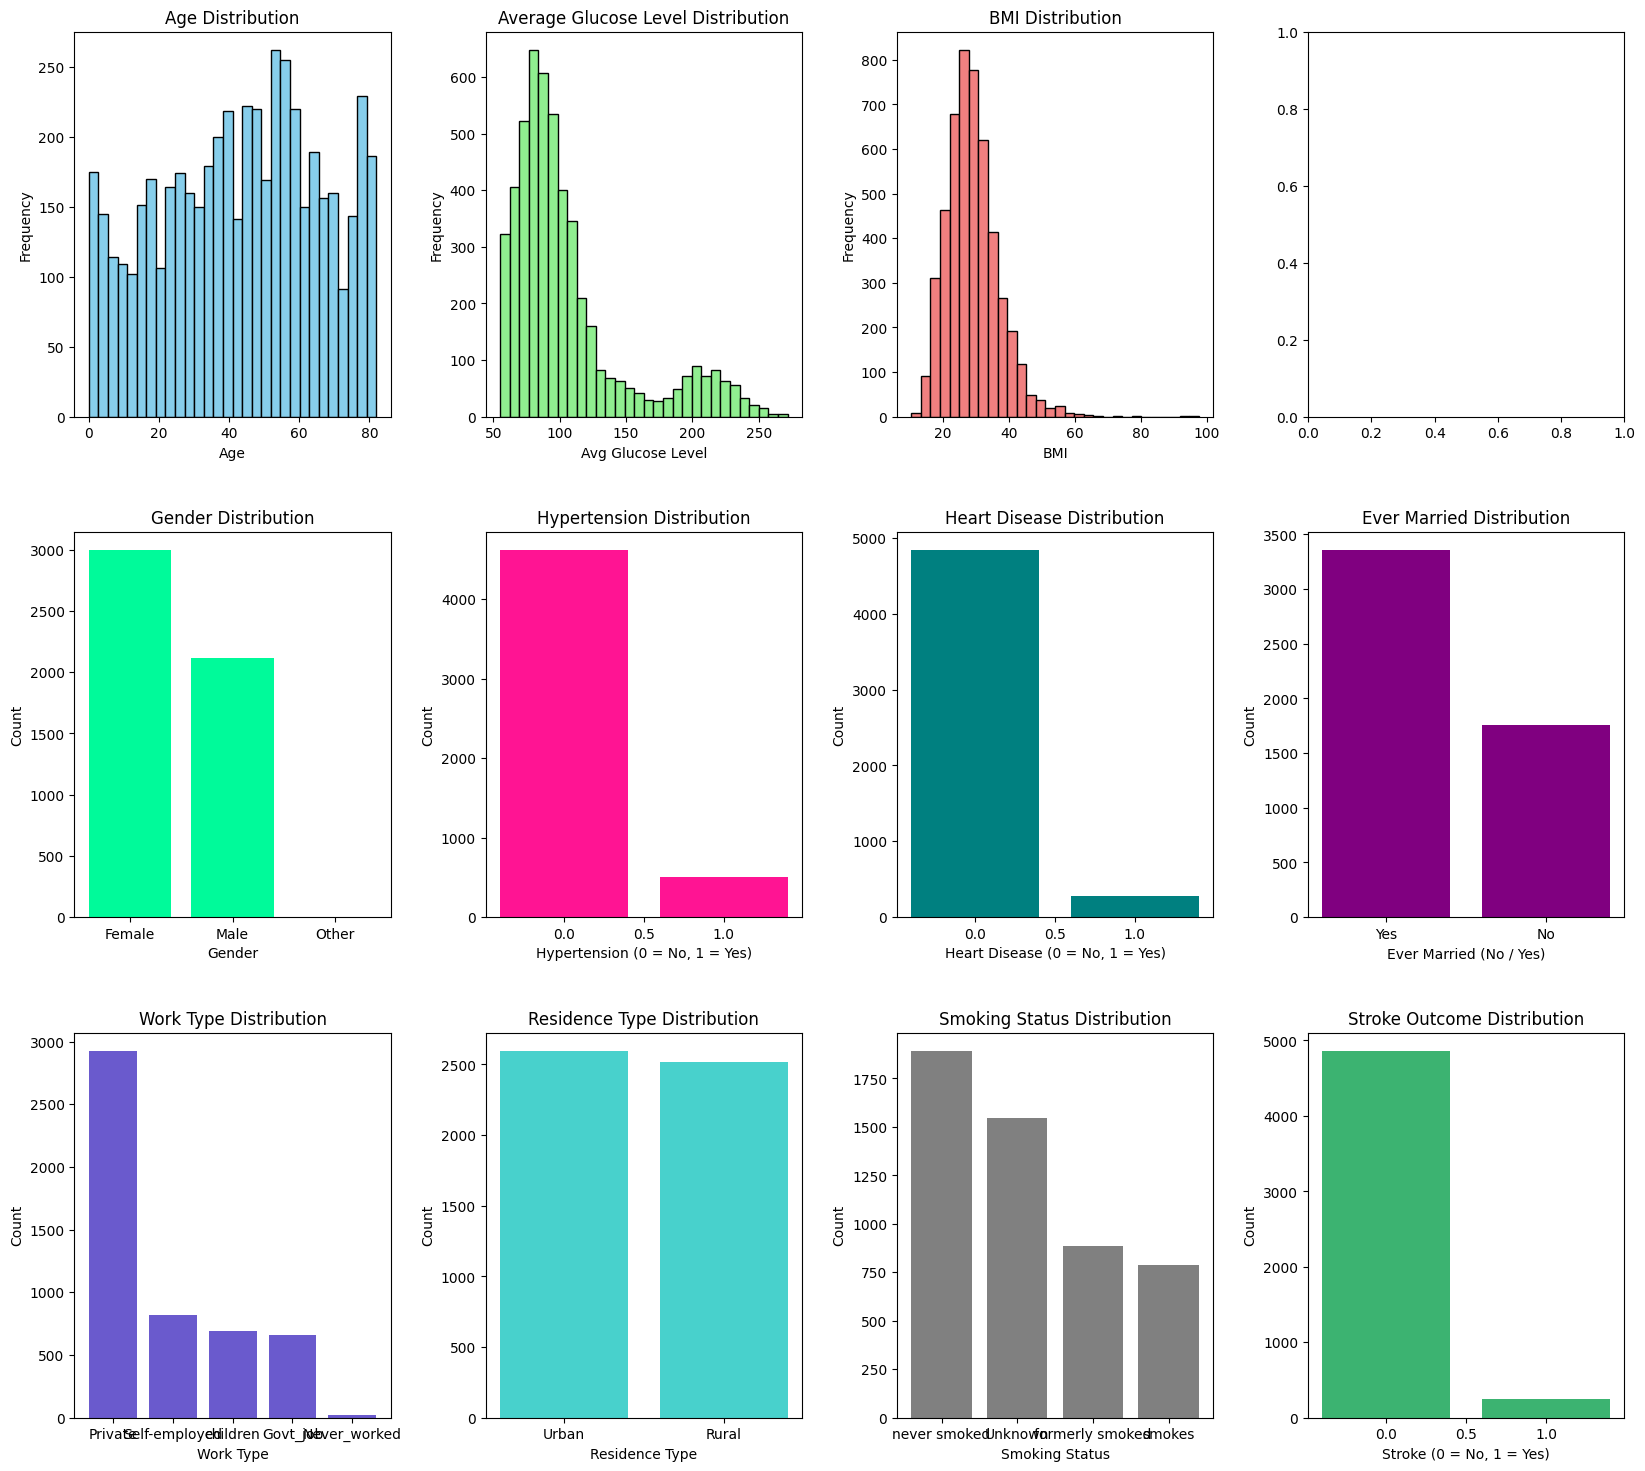

In [ ]:
# Set up the plot grid (3 rows, 4 columns)
fig, axes = plt.subplots(3, 4, figsize=(20, 18))  # 3 rows, 4 columns for a neat layout
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Histogram for continuous variables (with different colors)
axes[0, 0].hist(df['age'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df['avg_glucose_level'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Average Glucose Level Distribution')
axes[0, 1].set_xlabel('Avg Glucose Level')
axes[0, 1].set_ylabel('Frequency')

axes[0, 2].hist(df['bmi'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 2].set_title('BMI Distribution')
axes[0, 2].set_xlabel('BMI')
axes[0, 2].set_ylabel('Frequency')

# Bar plot for categorical variables (with different colors)
axes[1, 0].bar(df['gender'].value_counts().index, df['gender'].value_counts(), color=['#00fa9a'])
axes[1, 0].set_title('Gender Distribution')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Count')

axes[1, 1].bar(df['hypertension'].value_counts().index, df['hypertension'].value_counts(), color=['#ff1493'])
axes[1, 1].set_title('Hypertension Distribution')
axes[1, 1].set_xlabel('Hypertension (0 = No, 1 = Yes)')
axes[1, 1].set_ylabel('Count')

axes[1, 2].bar(df['heart_disease'].value_counts().index, df['heart_disease'].value_counts(), color=['#008080'])
axes[1, 2].set_title('Heart Disease Distribution')
axes[1, 2].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[1, 2].set_ylabel('Count')

axes[1, 3].bar(df['ever_married'].value_counts().index, df['ever_married'].value_counts(), color=['#800080'])
axes[1, 3].set_title('Ever Married Distribution')
axes[1, 3].set_xlabel('Ever Married (No / Yes)')
axes[1, 3].set_ylabel('Count')

# More bar plots for categorical variables
axes[2, 0].bar(df['work_type'].value_counts().index, df['work_type'].value_counts(), color=['#6a5acd'])
axes[2, 0].set_title('Work Type Distribution')
axes[2, 0].set_xlabel('Work Type')
axes[2, 0].set_ylabel('Count')

axes[2, 1].bar(df['Residence_type'].value_counts().index, df['Residence_type'].value_counts(), color=['#48d1cc'])
axes[2, 1].set_title('Residence Type Distribution')
axes[2, 1].set_xlabel('Residence Type')
axes[2, 1].set_ylabel('Count')

axes[2, 2].bar(df['smoking_status'].value_counts().index, df['smoking_status'].value_counts(), color=['#808080'])
axes[2, 2].set_title('Smoking Status Distribution')
axes[2, 2].set_xlabel('Smoking Status')
axes[2, 2].set_ylabel('Count')

axes[2, 3].bar(df['stroke'].value_counts().index, df['stroke'].value_counts(), color=['#3cb371'])
axes[2, 3].set_title('Stroke Outcome Distribution')
axes[2, 3].set_xlabel('Stroke (0 = No, 1 = Yes)')
axes[2, 3].set_ylabel('Count')

# Show the plot
plt.show()

The age distribution appears appears quite uniform, without strong skewness (it is slightly left-skewed.) There is a mix of participants across various age ranges, with more participants in the middle-aged and older groups.

The distribution of the average glucose level is very right-skewed and appears to be bimodal. The majority of participants has a normal glucose level, but there’s a significant subgroup with elevated levels. There’s a long tail toward higher glucose levels (with quite a few observations exceeding 200) that could indicate participants with potential prediabetes or diabetes.

The distribution of the Body Mass Index (BMI) is approximately normal but slightly right-skewed as well. There are a few outliers with very high BMIs, which may represent extreme cases of obesity.

The dataset is dominated by female participants and male participants.
It appears that there are no observations labeled as "Other." Since the "Other" category appears to be negligible I might be merged it or remove it to simplify analysis.

The majority of participants does not have hypertension or heart disease.

A larger proportion of participants has been married compared to those who have never been married. The distribution is somewhat imbalanced but not as extreme as hypertension or heart disease.

 The "Private" work type has the highest count. The categories "Self-employed", "Government" and "Children" all have significantly lower counts, each below 1000. A very small minority of the participants has never worked.

 The "Urban" and "Rural" residence types show a fairly even distribution, each with a count of around 2500 individuals.

 The majority of individuals has never smoked. "Unknown" is the next most prevalent category followed by "formerly smoked" and "smokes".

 There is a strong imbalance in the stroke outcome frequency distribution, with the vast majority of individuals not having had a stroke compared to a much smaller number of individuals who have had a stroke. I will need to apply oversampling techniques to balance the target variable.

#### Missing Values

In [ ]:
# We can count how many NaN values there are in each column
missing_values_per_column = df.isna().sum()
print("Missing values per column:")
print(missing_values_per_column)
print()

# We can also calculate the total number of NaN values in our entire Dataset
total_missing_values = df.isna().sum().sum()
print("Total missing Values:\t %.2f"%(total_missing_values))
print()

# Another informative thing to consider is the amount of rows (and therefore patients) with at least one NaN value
rows_with_missing_values = df.isnull().any(axis=1).sum()  #we are creating a dataframe with TRUE if values are missing, we are then converting the TRUE cells to 1 and summing all of them
print("Number of patients with at least one missing value:\t %.2f"%(rows_with_missing_values))

Missing values per column:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Total missing Values:	 201.00

Number of patients with at least one missing value:	 201.00


In [ ]:
unknown_smoking_count = len(df[df['smoking_status'] == 'Unknown'])
print("Unknown smoking count: \t%.2f"%(unknown_smoking_count))
percentage_unknown_smoking_count=unknown_smoking_count/len(df)
print("Percentage of patients with an unknown smoking status: \t %.2f"%(percentage_unknown_smoking_count))

Unknown smoking count: 	1544.00
Percentage of patients with an unknown smoking status: 	 0.30


In [ ]:
percentage_missing_values=rows_with_missing_values/len(df)
print("Percentage of missing values: \t %.2f"%(percentage_missing_values))

Percentage of missing values: 	 0.04


As we can see there are 1544 patients with an unknown smoking status and the dataset is missing 201 values, all from the Body Mass Index column.

Since the percentage of participants with an unknown smoking status is very high (= 30%) eliminating all of them from the dataset would very significantly reduce the information at my disposal. At the same time, trying to imputate so many categories could introduce a big amount of bias and artificial patterns in the data, and we should also consider the possibility that the unknown category might actually represent a potentially meaningful group (e.g., patients who didn’t disclose smoking status might share common traits).

Because of all these reasons I will leave the smoking status column as it is and simply proceed with data analysis operations on the data.

Pertaining to the BMI column, by using the `dropna` function and simply eliminating all the rows with missing values I would reduce my dataset by 4%. By imputing these values I also shouldn't be introducing an amount of bias comparable to the one I would be introducing if I imputed the unknown smoking statuses.

So to avoid losing valuable data I will use Nearest Neighbours Imputation: an imputation method that finds data points similar to the ones with the missing value and uses the weighted average of their values to estimate the missing attributes.  `KNNImputer`  is a reasonable choice because:

*   it estimates BMI based on similar patients.
* BMI is a numerical and continuous variable making KNN a good fit.
* KNN considers multiple variables to estimate BMI


 `KNNImputer` works by calculating distances between data points, and this requires all features to be numerical.
So, to use Nearest Neighbours Imputation I first need to change the categorical values in my dataframe to numerical values.

#### Encoding

In [ ]:
print(df['gender'].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


There is only one 'Other' observation in a dataset of 5110 people. Since there is only one 'Other' occurrence, it will not contribute meaningful insights and might add noise.
 A separate category for just one row can cause models (especially decision trees) to overfit and learn an artificial pattern.
Furthermore one-hot encoding for just one row wastes a feature column.
Because of all of these considerations  I consider a better to simply drop the "Other" row.

In [ ]:
df = df[df['gender'] != 'Other'] # to drop the row with the "Other" value
df.reset_index(drop=True, inplace=True) # Reset the index
print(df['gender'].value_counts())

gender
Female    2994
Male      2115
Name: count, dtype: int64


 Now  I need to convert the categorical data into numerical data. I will use two techniques: Label Encoding and One-Hot Encoding.  

*   Since the 'gender', 'ever married' and 'residence' columns contain binary categorical features I will use label encoding.
*   Since smoking status and work type have more than two categories I will use One-Hot Encoding to prevent false ordinal relationships. One-hot encoding creates new columns for each category, and assigns a 1 or 0 to indicate whether a particular row belongs to that category.







After hot one encoding my variables I will drop one column each. This terensures numerical stability and simplifies the feature space, without affecting the performance of any of the suggested models. If I wer to keep all the columns, the encoded variables would be perfectly collinear.

Not dropping one column for tree-based models (Random Forest, XGBoost), has a  negligible impact but adds redundancy to the feature space. However, for linear models (Logistic Regression), multicollinearity ca be an issue, making the models less reliable.

In [ ]:
# Encoding Gender (Label Encoding since it's binary)
df.loc[:,'gender'] =  df.loc[:,'gender'].map({'Male': 0, 'Female': 1})

# Encoding Ever Married (Label Encoding since it's binary)
df.loc[:,'ever_married'] =  df.loc[:,'ever_married'].map({'No': 0, 'Yes': 1})

# Encoding Residence Type (Label Encoding since it's binary)
df.loc[:,'Residence_type'] =  df.loc[:,'Residence_type'].map({'Rural': 0, 'Urban': 1})

# Encoding Work Type (One-Hot Encoding)
df = pd.get_dummies(df, columns=['work_type'], drop_first=True, dtype=int)

# Encoding Smoking Status (One-Hot Encoding)
df = pd.get_dummies(df, columns=['smoking_status'], drop_first=True, dtype=int)

I will also drop the id column. Since it is just a unique identifier for each patient, it doesn't carry any predictive information about the likelihood of a stroke. And keeping it would add confusion to the dataset.

In [ ]:
df.drop('id', axis=1, inplace=True)  #axis=1 drop a column and not a row
print(df[5020:5110])

     gender   age  hypertension  heart_disease ever_married Residence_type  \
5020      1  35.0             0              0            1              1   
5021      1  40.0             0              0            0              0   
5022      1  37.0             0              0            0              0   
5023      0  33.0             0              0            1              0   
5024      1  35.0             0              0            1              1   
...     ...   ...           ...            ...          ...            ...   
5104      1  80.0             1              0            1              1   
5105      1  81.0             0              0            1              1   
5106      1  35.0             0              0            1              0   
5107      0  51.0             0              0            1              0   
5108      1  44.0             0              0            1              1   

      avg_glucose_level   bmi  stroke  work_type_Never_worked  

Since KNNImputer works by calculating distances between data points I have to standardize the data; otherwise features with larger scales can disproportionately influence the distance calculations, leading to biased imputation.

But I want to avoid data leakage, so I will split the data into a training and test set before proceeding with standardization and imputation.

#### Splitting and scaling the dataset

In [ ]:
X = df.drop('stroke', axis=1)  # defining my predictors as as all columns except stroke
y = df['stroke']  # stroke = target variable

Splitting the dataset:

In [ ]:
x_tr, x_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=7)

Considering the distributions I analyzed previously I will:
* normalize the average glucose level with minMaxScaler. This makes sense because it is better for skewed distributions.
* bmi and age seemed decently gaussian so I will scale use StandardScaler

In [ ]:
scaler = StandardScaler()
sc=MinMaxScaler()

x_tr['avg_glucose_level'] = sc.fit_transform(x_tr[['avg_glucose_level']])
x_te['avg_glucose_level'] = sc.transform(x_te[['avg_glucose_level']])

x_tr['age'] = scaler.fit_transform(x_tr[['age']])
x_te['age'] = scaler.transform(x_te[['age']])

x_tr['bmi'] = scaler.fit_transform(x_tr[['bmi']])
x_te['bmi'] = scaler.transform(x_te[['bmi']])

#### Imputation (KNN)

Now that I have preprocessed and scaled the data, I can proceed with imputation. I will fit the imputer on the training data and then transform both the training and test data using the same fitted imputer.

In [ ]:
imputer = KNNImputer(n_neighbors=5)  # I kind of chose the number of neighbors arbitrarily

# I will fit the imputer on the training data only
imputer.fit(x_tr)

# After that transform the training data:
x_tr_imputed = imputer.transform(x_tr)

# Then transform the test data:
x_te_imputed = imputer.transform(x_te)

# Update the training and test dataframes:
x_tr['bmi'] = x_tr_imputed[:, x_tr.columns.get_loc('bmi')]
x_te['bmi'] = x_te_imputed[:, x_te.columns.get_loc('bmi')]

In [ ]:
print(x_tr) # as we can see there are no more Nan values

     gender       age  hypertension  heart_disease ever_married  \
4066      1 -0.678554             0              0            1   
4185      1 -1.032707             0              0            0   
3560      0 -0.722823             0              0            0   
3466      1 -0.855631             0              0            1   
3744      1 -0.634285             0              0            0   
...     ...       ...           ...            ...          ...   
4307      1  1.047939             0              0            1   
2550      0  0.516710             0              0            1   
537       0  0.959401             0              0            1   
1220      1 -1.032707             0              0            0   
4271      1 -1.165514             0              0            0   

     Residence_type  avg_glucose_level       bmi  work_type_Never_worked  \
4066              1           0.198181 -0.530540                       0   
4185              0           0.300526 -0.9

#### Balancing the dataset (SMOTE)

My dataset is quite imbalanced. Let's see by how much:

In [ ]:
print("Class distribution before SMOTE:")
print(y_tr.value_counts())


Class distribution before SMOTE:
stroke
0    3888
1     199
Name: count, dtype: int64


As we can see only 199 participants out of 38888 have had a stroke. The imbalance ratio is approximately 19:1  (since 3888/199=19.537).

Training the models on such an imbalanced dataset can be deceptive, as the models might focus on the majority class (non-stroke) and ignore the minority class (stroke cases). This could result in deceptively high accuracy metrics, where the model predicts 'no stroke' for almost all observations, but fails to identify the minority class accurately.

With SMOTE I will synthesize new data samples  in order to increase the number of patterns belonging to the stroke (1) class.


Not altering the test set with SMOTE prevents data leakage and provides a realistic measure of how well the model performs on real-world data, ensuring that the improvements achieved by SMOTE translate into practical, generalizable insights

In [ ]:
# Create smote
smote = SMOTE(sampling_strategy=1, random_state=7)  # You can adjust the random_state for reproducibility

# Apply SMOTE to the training data
x_tr_res, y_tr_res = smote.fit_resample(x_tr, y_tr)

In [ ]:
print("Class distribution after SMOTE:")
print(y_tr_res.value_counts())


Class distribution after SMOTE:
stroke
0    3888
1    3888
Name: count, dtype: int64


Now the classes are balanced.

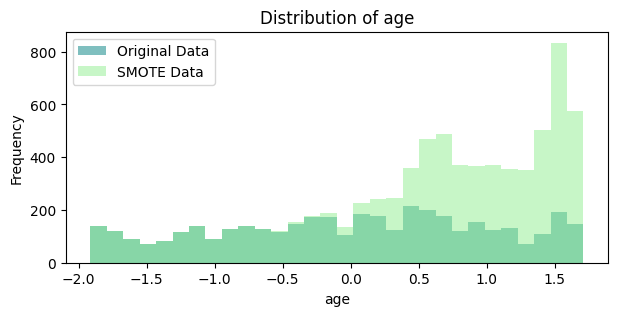

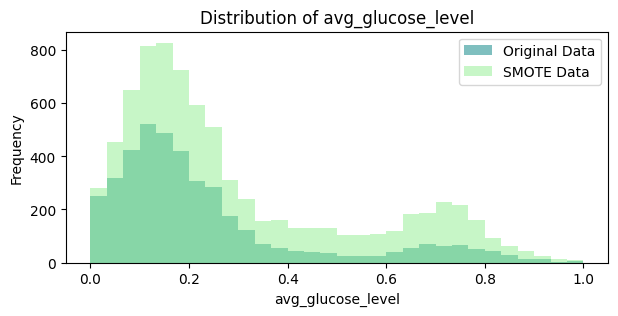

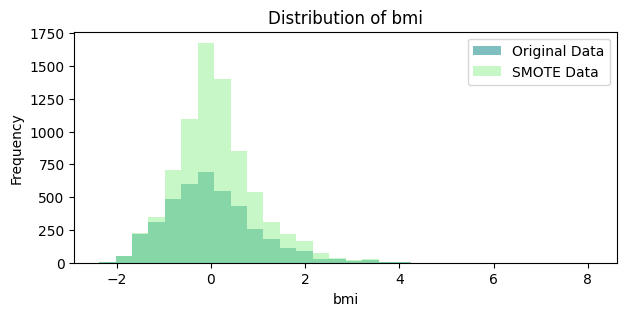

In [ ]:
# Function to create histograms for comparison
def plot_histograms(original_data, smote_data, feature_name):
    """Plots histograms of a feature before and after SMOTE."""
    plt.figure(figsize=(7, 3))
    plt.hist(original_data[feature_name], bins=30, alpha=0.5, label='Original Data',color=['#008080'])
    plt.hist(smote_data[feature_name], bins=30, alpha=0.5, label='SMOTE Data', color='lightgreen')
    plt.title(f'Distribution of {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

# Select features for comparison
features_to_compare = ['age', 'avg_glucose_level', 'bmi']  # Add more features as needed

# Create histograms for selected features
for feature in features_to_compare:
    plot_histograms(x_tr, x_tr_res, feature)  # x_tr is original, x_tr_res is after SMOTE


It is evident that the new synthetic data has changed the distribution of age: it has shifted and is now left-skewed. It appears that in the  original dataset the minority class (stroke = 1) had more older individuals. SMOTE has produced more samples in the older age range, which aligns with the expected demographic of stroke patients. This shift in the distribution should not be problematic because I believe it mirrors real-world trends.

#### Investigating Variance and Dimensionality

I will also try to determine if it is necessary to reduce the dimensionality of my dataset. This  could help with computational efficiency and reducing the risk of overfitting by eliminating redundant features.

In [ ]:
pca = PCA(.95)
pca.fit(x_tr_res)
print("Number of components:", pca.n_components_)
print("Total explained variance: %.2f" % np.sum(pca.explained_variance_ratio_))

Number of components: 11
Total explained variance: 0.97


PCA has extracted 11 principal components which explain around 97% of the variance in the oversampled dataset. So by using PCA I would only be reducing the dimensionality of my dataframe from 15 features to 11 principal components.

In [ ]:
x_tr_pca = pca.transform(x_tr_res)
x_te_pca = pca.transform(x_te)

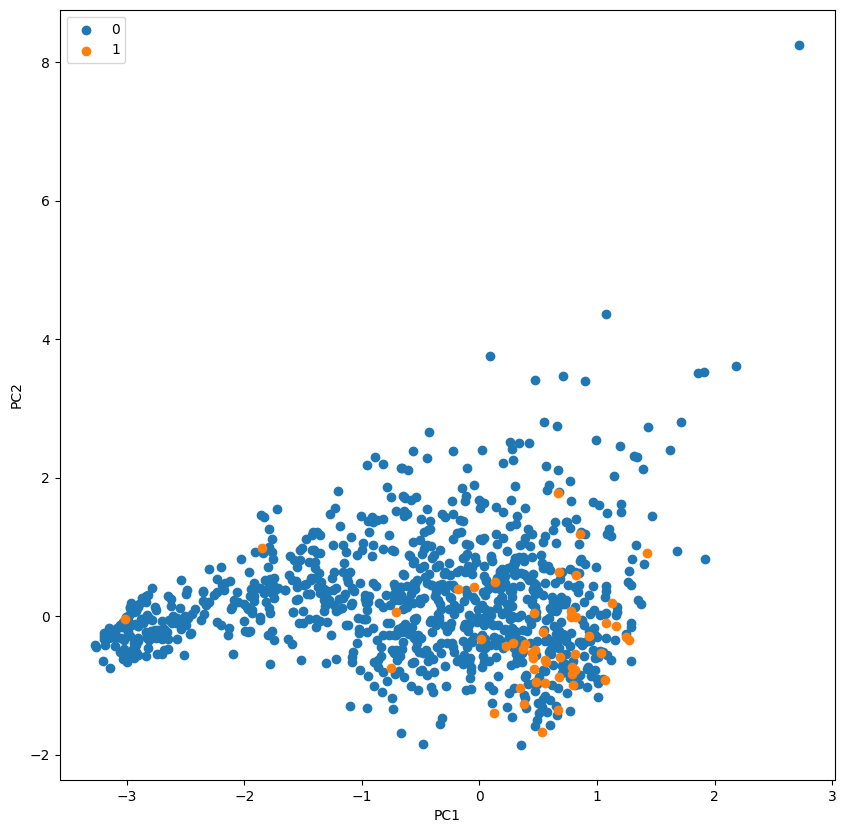

In [ ]:
plt.figure(figsize=(10,10));
for c in np.unique(y_te):
    i = np.where(y_te == c)
    plt.scatter(x_te_pca[i,0], x_te_pca[i,1], label=c)
    # I am plotting the data based only on the first 2 components
plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

The two first principal components don't seem to separate the classes very well.

By using PCA, I could also lose interpretability of the original features. I believe that understanding which features are important (e.g., age, gender, smoking status) is crucial, so PCA may not be ideal.
Overall the advantages are minor and I will not be using it for the next steps.

#### Model Implementation

I will treat predicting the probability of having a stroke as a binary classification problem.  I will implement several models to compare their performance and afterwards choose the most suitable for the task. Models charachteristics:

* I will use logistic regression as a baseline model. It is a good starting point because it is simple, interpretable and estimates probabilities directly. It is computationally efficient and useful for understanding the significance of different features, such as age, hypertension, and smoking status. However, it assumes a linear relationship between the independent variables and the log-odds of having a stroke. If the actual relationship is highly non-linear, its performance may suffer.
* I will also use a non-linear Support Vector Machine (SVM). I will not implement a linear SVM because it is similar to logistic regression and separates the data by a straight hyperplane. However, the non-linear SVM with the radial basis function (RBF) kernel will map the input features into a higher-dimensional space, enabling it to capture complex relationships between risk factors that logistic regression might miss. This is a more powerful approach compared to logistic regression, but it is more computationally expensives.
* I will also implement a K-Nearest Neighbors (KNN) model. It is a powerful approach that classifies new observations based on the majority class of their closest neighbors. It could be really useful to see if patients with similar characteristics are likely to have similar stroke risks. However, KNN is computationally demanding since it requires computing distances for every new prediction, making it inefficient for large datasets. Additionally, its performance can degrade if there are many categorical or irrelevant features in the dataset, as they can distort distance calculations.
* Decision trees offer a highly interpretable model that recursively splits the data based on the most informative features. It can capture non-linear relationships and interactions between risk factors. However, a single decision tree is prone to overfitting, meaning that it may model noise in the training data rather than the actual stroke risk patterns.
* Random forests construct multiple trees on different subsets of the data and average their predictions. This reduces variance and improves generalization, making random forests one of the most robust models for structured medical data. Moreover, they provide feature importance scores, which will allow me to understand which factors contribute the most to stroke risk. Despite all of these advantages, random forests can be computationally intensive, especially when the number of trees is large, and they can still suffer from interpretability issues compared to simpler models like logistic regression.
* XGBoost works by training decision trees sequentially, where each tree corrects the errors of the previous ones, leading to a highly optimized predictive model. They are particularly effective when dealing with imbalanced datasets, as they can focus learning on the minority class (stroke cases) to improve detection rates. However, they require careful hyperparameter tuning to avoid overfitting and to maximize their predictive power.


In this project, I will test all of these models to identify the optimal balance between recall, interpretability, and computational efficiency. Logistic regression will serve as the baseline, while more complex models such as SVM, KNN, decision trees, random forests, and gradient boosting will be evaluated for improved predictive performance. Model evaluation will be based on metrics such as precision-recall, F1-score, and ROC-AUC, with an emphasis on selecting a model that provides reliable and interpretable predictions for stroke risk assessment. In the case of similar performance, I will prioritize the least computationally expensive and complex model.


Fitting the models on the oversampled dataset.

In [ ]:
model_logistic = LogisticRegression(max_iter=10000).fit(x_tr_res, y_tr_res);
model_svm_nonlin = SVC(kernel="rbf", gamma=2, C=1).fit(x_tr_res, y_tr_res);
model_knn = KNeighborsClassifier(5).fit(x_tr_res, y_tr_res);
model_tree = DecisionTreeClassifier().fit(x_tr_res, y_tr_res);
model_forest = RandomForestClassifier(n_estimators=10).fit(x_tr_res, y_tr_res);
model_xgb = GradientBoostingClassifier().fit(x_tr_res, y_tr_res);

In [ ]:
print("\t\t TR \t TE")
print("Logistic acc:\t %.2f\t %.2f" % (model_logistic.score(x_tr_res, y_tr_res), model_logistic.score(x_te, y_te)))
print("SVM-RBF acc:\t %.2f\t %.2f" % (model_svm_nonlin.score(x_tr_res, y_tr_res), model_svm_nonlin.score(x_te, y_te)))
print("KNN acc:\t %.2f\t %.2f" % (model_knn.score(x_tr_res, y_tr_res), model_knn.score(x_te, y_te)))
print("Tree acc:\t %.2f\t %.2f" % (model_tree.score(x_tr_res, y_tr_res), model_tree.score(x_te, y_te)))
print("Forest acc:\t %.2f\t %.2f" % (model_forest.score(x_tr_res, y_tr_res), model_forest.score(x_te, y_te)))
print("Xgb acc:\t %.2f\t %.2f" % (model_xgb.score(x_tr_res, y_tr_res), model_xgb.score(x_te, y_te)))

		 TR 	 TE
Logistic acc:	 0.79	 0.75
SVM-RBF acc:	 0.96	 0.86
KNN acc:	 0.93	 0.80
Tree acc:	 1.00	 0.86
Forest acc:	 1.00	 0.89
Xgb acc:	 0.90	 0.82


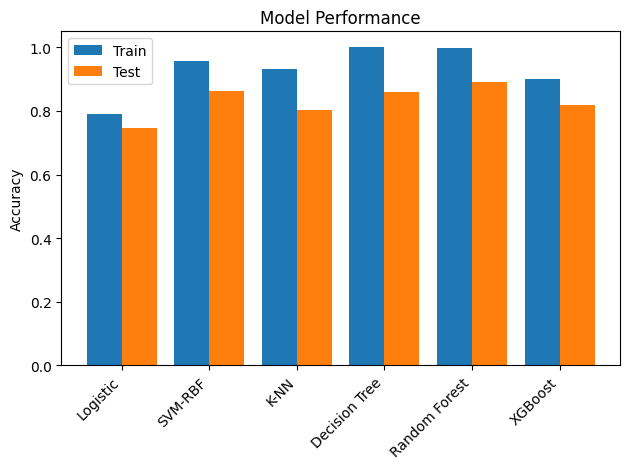

In [ ]:
trainscores = [model_logistic.score(x_tr_res, y_tr_res), model_svm_nonlin.score(x_tr_res, y_tr_res), model_knn.score(x_tr_res, y_tr_res),
               model_tree.score(x_tr_res, y_tr_res), model_forest.score(x_tr_res, y_tr_res), model_xgb.score(x_tr_res, y_tr_res)]

testscores = [model_logistic.score(x_te, y_te), model_svm_nonlin.score(x_te, y_te), model_knn.score(x_te, y_te),
              model_tree.score(x_te, y_te), model_forest.score(x_te, y_te), model_xgb.score(x_te, y_te)]

model_names = ['Logistic', 'SVM-RBF', 'K-NN', 'Decision Tree', 'Random Forest', 'XGBoost']
x_pos = np.arange(len(model_names))  # X-axis = we assign positions for the bars so that they don't overlap

#plt.bar(x, height, width=0.8, bottom=None, *, align='center', data=None, **kwargs)
#to obtain what we want remember that: x is the position of the bars,
# height is the variable wewant to visualize (= accuracy scores = altezza delle barre)

plt.bar(x_pos - 0.2, trainscores, width=0.4, label='Train')
plt.bar(x_pos + 0.2, testscores, width=0.4, label='Test')

plt.xticks(x_pos, model_names, rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.ylabel('Accuracy')
plt.title('Model Performance')
plt.legend()
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

The models are overfitting the data.

In any case, for my purposes accuracy is not a very relevant metric for model performance. In fatc when trying to predict a dangerous medical condition (such as stroke) it is more important to prioritize the identification of at risk individuals even if it slightly increases the rate of false positives.

Therefore I will also check the ROCs, confusion matrices, precision, recall and F1 score of each model.

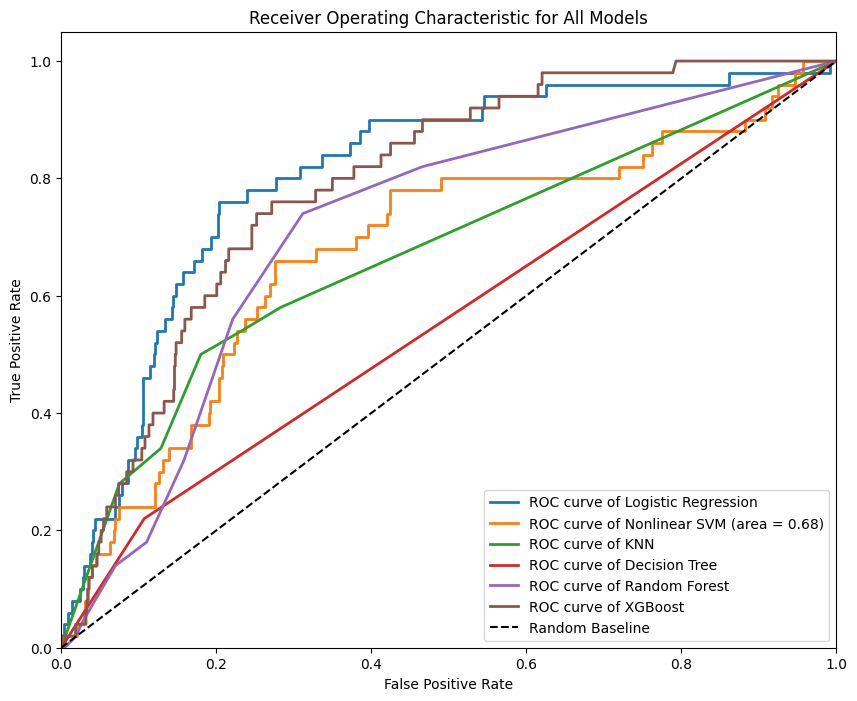

In [ ]:
models = {
    "Logistic Regression": model_logistic,
    "Nonlinear SVM": model_svm_nonlin,
    "KNN": model_knn,
    "Decision Tree": model_tree,
    "Random Forest": model_forest,
    "XGBoost": model_xgb}



# ROC
plt.figure(figsize=(10, 8))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_te)[:, 1]  # Probability for class 1 (stroke)
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        plt.plot(fpr, tpr, lw=2, label=f"ROC curve of {name}")
    else:
        y_score = model.decision_function(x_te)  # Use decision_function for SVM
        fpr, tpr, _ = roc_curve(y_te, y_score)
        roc_auc = auc(fpr, tpr)  # Calculate AUC for SVM
        plt.plot(fpr, tpr, lw=2, label=f"ROC curve of {name} (area = {roc_auc:.2f})")

# Plot the random baseline
plt.plot([0, 1], [0, 1], color="k", linestyle="--", label="Random Baseline")

# Add labels and legend
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic for All Models")
plt.legend(loc="lower right")
plt.show()

The Receiver Operating Characteristic curve of logistic regression, xgboost and random forest already seems pretty good. On the contrary, KNN and the decision tree model in particular don't seem to be differentiating the stroke classes very well.

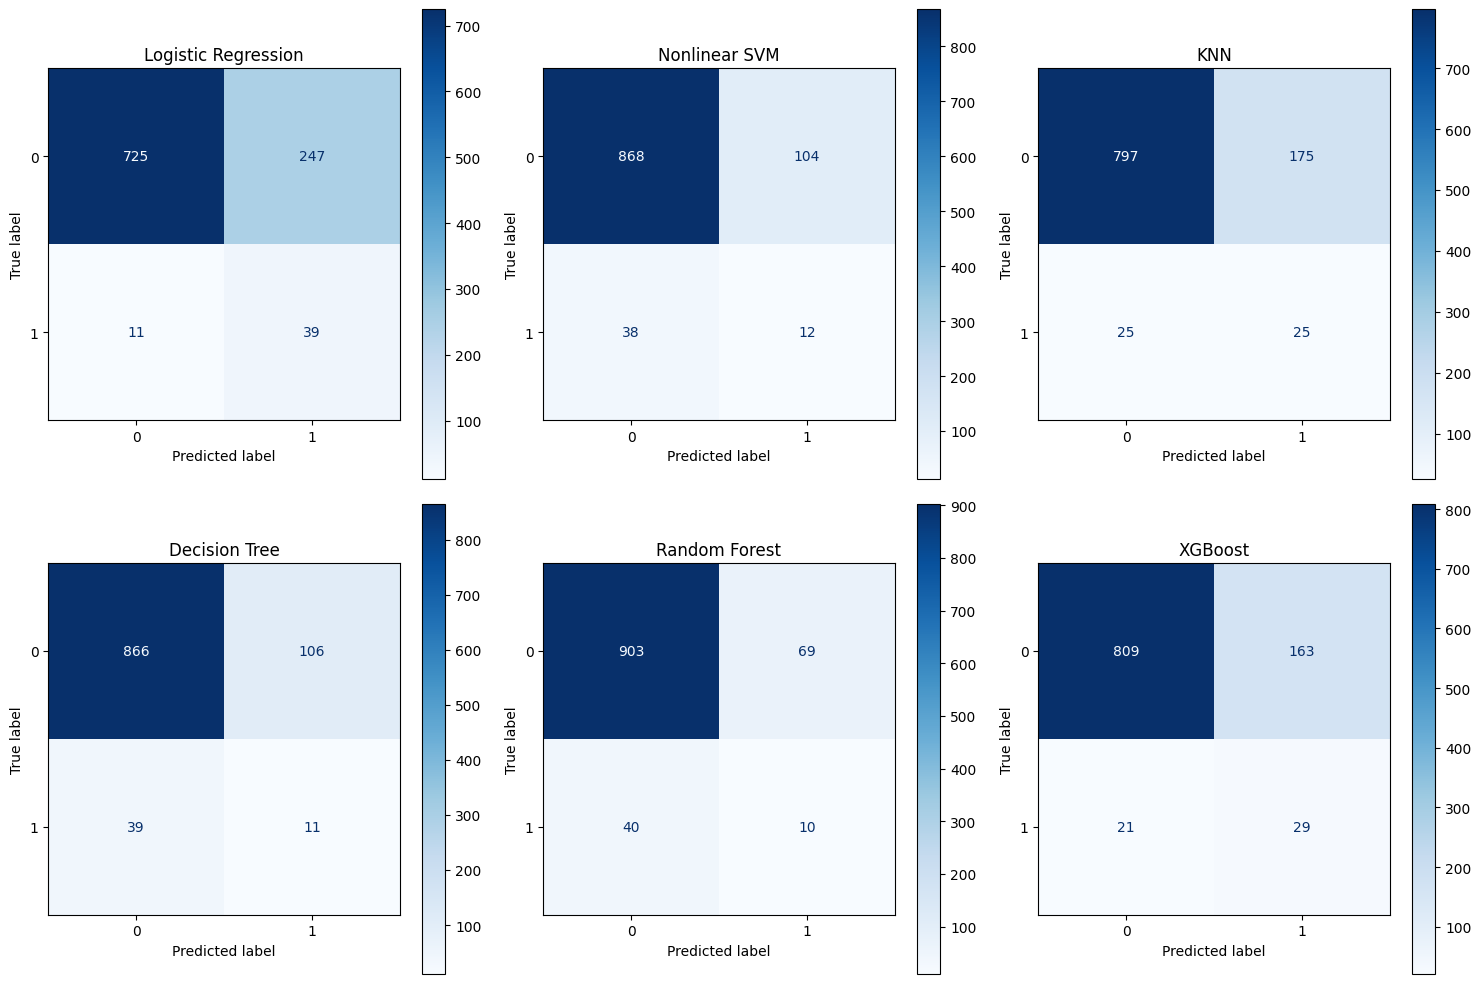

In [ ]:
models = {
    "Logistic Regression": model_logistic,
    "Nonlinear SVM": model_svm_nonlin,
    "KNN": model_knn,
    "Decision Tree": model_tree,
    "Random Forest": model_forest,
    "XGBoost": model_xgb}

# Create a figure and axes for the 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # Adjust figsize as needed

# Flatten the axes array for easier iteration
axes = axes.ravel()

# Iterate through models, calculate and plot confusion matrices
for i, (name, model) in enumerate(models.items()):
    model.fit(x_tr_res, y_tr_res)  # Fit the model on training data
    y_pred = model.predict(x_te)  # Get predictions for test data
    cm = confusion_matrix(y_te, y_pred)  # Calculate confusion matrix

    # Display confusion matrix on the current subplot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes[i], cmap=plt.cm.Blues)  # Use a colormap (e.g., Blues)
    disp.ax_.set_title(name)  # Set title for the subplot

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [ ]:
# Iterate through best_models and print metrics
for name, model in models.items():
    y_pred = model.predict(x_te)  # Predictions on the test set

    # Calculate metrics
    accuracy = accuracy_score(y_te, y_pred)
    precision = precision_score(y_te, y_pred)
    recall = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)

    # Print metrics with model name
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\n")  # Empty row for better visualization

Model: Logistic Regression
Accuracy: 0.7476
Precision: 0.1364
Recall: 0.7800
F1 Score: 0.2321


Model: Nonlinear SVM
Accuracy: 0.8611
Precision: 0.1034
Recall: 0.2400
F1 Score: 0.1446


Model: KNN
Accuracy: 0.8043
Precision: 0.1250
Recall: 0.5000
F1 Score: 0.2000


Model: Decision Tree
Accuracy: 0.8581
Precision: 0.0940
Recall: 0.2200
F1 Score: 0.1317


Model: Random Forest
Accuracy: 0.8933
Precision: 0.1266
Recall: 0.2000
F1 Score: 0.1550


Model: XGBoost
Accuracy: 0.8200
Precision: 0.1510
Recall: 0.5800
F1 Score: 0.2397




The diagonals of the confuzion matrixes overall don't look very good. But it could also be due to the prediction tresholds or decision boundaries of the models. By default models use a treshold of 0.5 to classify a sample as positive or negative, and in our case maybe the treshold should be lowered.

As we can see despite the accuracy being very high the other performance metrics are not as good. The Precision, Recall and F1 Score of all the models, are quite low.

These results were achieved with a fairly random choice of hyperparameters and acompletely arbitrary prediction treshold (or decision boundary).
As it is all models, except logistic regression, are quite conservative in predicting positive outcome. This serves as a crucial sign that the models need improvement.


I will address the problem by exploiting a random-search cross-validation approach.
After that I will evaluate and compare the performance of my models.

#### Tuning Model Hyperparameters

Given the size of the dataset and the number of models I am implementing, I will use a two-step hyperparameter optimization approach:
* first use RandomSearch for hyperparameter tuning because it is more computationally efficient and faster compared to GridSearch. With a large hyperparameter space, particularly for models like Random Forest and SVM, RandomSearch it can effectively explore random combinations of hyperparameters, allowing me to quickly identify a good set of parameters. This approach enables a faster evaluation of hyperparameters, saving both time and computational resources, while still ensuring good model performance on my dataset.
* after identifying the promising regions with Random Search, I will fine-tune the models with Grid Search by exhaustively searching over this smaller, refined space.

I first need to define hyperparameter grids for my machine learning models.

In [ ]:
# Logistic Regression
param_logistic_regression = {
    'penalty': ['elasticnet'], 'C': np.arange(0.1, 10.1, 0.2).tolist(), 'l1_ratio': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], 'solver': ['saga']}
     # hyperparameter space from 0.1 to 10 increasing by 0.2 # it creates an array containing a sequence of numbers and then it converts it into a list

# Support Vector Machine with RBF Kernel
param_svm = {
    'C': np.arange(0.01, 10.01, 0.3).tolist(),  # 0.01 to 10 increasing by 0.3
    'gamma': np.arange(0.001, 0.1, 0.01).tolist(),  # 0.001 to 0.1 increasing by 0.01
    'kernel': ['rbf']}

# K-Nearest Neighbors (KNN)
param_knn= {
    'n_neighbors': list(range(1, 101, 2)),  # 1 to 100 increasing by 2  #this range function creates a sequence of numbers (it stops before 101) and list transforms it into a list
    'weights': ['uniform', 'distance']}

# Decision Tree
param_decision_tree = {
    'max_depth': list(range(1, 31, 2)),  # 1 to 30 increasing by 2
    'min_samples_split': list(range(2, 51, 2)),  # 2 to 50 increasing by 2
    'min_samples_leaf': list(range(1, 51, 2))}  # 1 to 50 increasing by 2

# Random Forest
param_random_forest = {
    'n_estimators': list(range(50, 601, 50)),  # 50 to 700 increasing by 50
    'max_depth': list(range(1, 31,3)),  # 1 to 30 increasing by 3
    'min_samples_split': list(range(2, 51, 2)),  # 2 to 50 increasing by 2
    'min_samples_leaf': list(range(1, 51, 2))}  # 1 to 50 increasing by 2

# XGBoost
param_xgboost = {
    'n_estimators': list(range(50, 601, 50)),  # 50 to 700 increasing by 50
    'subsample': np.arange(0.5, 1.01, 0.1).tolist(), #for regularizing
    "min_samples_split": list(range(2, 11, 2)),   ## 2 to 10 increasing by 2
    'learning_rate': np.arange(0.01, 0.31, 0.05).tolist(),  # 0.01 to 0.3 increasing by 0.05
    'max_depth': list(range(1, 21, 3))}  # 1 to 20 increasing by 3


I chose the granularity of my hyperparameter space to ensure that Randomized Search explores a diverse set of configurations without wasting iterations. Each model's hyperparameter space is significantly larger than the 30 iterations I selected, preventing redundant selections. Possible combinations:
 * Logistic Regression: 1 x 50 x 11 x 1 = 550
 * Support Vector Machine_ 34 x 10 x 1 = 340
 * K-Nearest Neighbors: 50 x 2 = 100
 * Decision Tree: 15 x 25 x 25 = 9375
 * Random Forest: 12 x 10 x 25 x 25 = 75000
 * XGBoost: 12 x 6 x 5 x 7 x 7 = 17640


I chose 30 iterations as a balance between efficiency and thorough exploration—enough to find strong hyperparameters without excessive computation, especially given the use of 5-fold cross-validation across six models. While larger hyperparameter spaces (like Random Forest and XGBoost) could benefit from more iterations, I consider 30 iterations as a reasonable tradeoff based on my computational constraints. Especially considering I will also operate a gridsearch afterwards.

In total, I will be training 50 models per model type, resulting in 50 x 5 folds = 250 training runs per model.

During hyperparameter optimization I will use the area under the receiver charachteristics curve to score the models. roc_auc evaluates the model's performance across all possible classification thresholds, making it less sensitive to the specific threshold chosen.

If the model separates the two classes well, it will have a good ROC AUC score.

In [ ]:
best_models = {}
best_params = {}

# Define a dictionary to map models to their hyperparameter grids
param_grids = {
    "Logistic Regression": param_logistic_regression,
    "Nonlinear SVM": param_svm,
    "KNN": param_knn,
    "Decision Tree": param_decision_tree,
    "Random Forest": param_random_forest,
    "XGBoost": param_xgboost}



# Initialize RandomizedSearchCV
for name, model in models.items():
    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_grids[name],  # Pass the correct hyperparameter grid
        n_iter=30,
        cv=5,
        scoring='roc_auc',
        random_state=7,
        n_jobs=-1)

    # Fit RandomizedSearchCV
    random_search.fit(x_tr_res, y_tr_res)

    # Store the best model and parameters
    best_models[name] = random_search.best_estimator_
    best_params[name] = random_search.best_params_

    print(name)
    print(random_search.best_score_)
    print(random_search.best_params_)
    print(random_search.best_estimator_)
    print("\n")

Logistic Regression
0.8601057098040332
{'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 1, 'C': 9.700000000000001}
LogisticRegression(C=9.700000000000001, l1_ratio=1, max_iter=10000,
                   penalty='elasticnet', solver='saga')


Nonlinear SVM
0.9316935061901059
{'kernel': 'rbf', 'gamma': 0.08099999999999999, 'C': 9.91}
SVC(C=9.91, gamma=0.08099999999999999)


KNN
0.9644094467940796
{'weights': 'distance', 'n_neighbors': 17}
KNeighborsClassifier(n_neighbors=17, weights='distance')


Decision Tree
0.9279796047450569
{'min_samples_split': 34, 'min_samples_leaf': 5, 'max_depth': 25}
DecisionTreeClassifier(max_depth=25, min_samples_leaf=5, min_samples_split=34)


Random Forest
0.9745967207862781
{'n_estimators': 400, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_depth': 28}
RandomForestClassifier(max_depth=28, min_samples_leaf=5, min_samples_split=4,
                       n_estimators=400)


XGBoost
0.9960484864919807
{'subsample': 0.8999999999999999, 'n_estimators

In [ ]:
print(best_models)
print(best_params)


{'Logistic Regression': LogisticRegression(C=9.700000000000001, l1_ratio=1, max_iter=10000,
                   penalty='elasticnet', solver='saga'), 'Nonlinear SVM': SVC(C=9.91, gamma=0.08099999999999999), 'KNN': KNeighborsClassifier(n_neighbors=17, weights='distance'), 'Decision Tree': DecisionTreeClassifier(max_depth=25, min_samples_leaf=5, min_samples_split=34), 'Random Forest': RandomForestClassifier(max_depth=28, min_samples_leaf=5, min_samples_split=4,
                       n_estimators=400), 'XGBoost': GradientBoostingClassifier(learning_rate=0.16000000000000003, max_depth=16,
                           n_estimators=450, subsample=0.8999999999999999)}
{'Logistic Regression': {'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 1, 'C': 9.700000000000001}, 'Nonlinear SVM': {'kernel': 'rbf', 'gamma': 0.08099999999999999, 'C': 9.91}, 'KNN': {'weights': 'distance', 'n_neighbors': 17}, 'Decision Tree': {'min_samples_split': 34, 'min_samples_leaf': 5, 'max_depth': 25}, 'Random Fore

### Evaluating model performance

Area under the curve of Logistic Regression:	 0.81
Area under the curve of Nonlinear SVM:	 0.74
Area under the curve of KNN:	 0.74
Area under the curve of Decision Tree:	 0.73
Area under the curve of Random Forest:	 0.78
Area under the curve of XGBoost:	 0.78


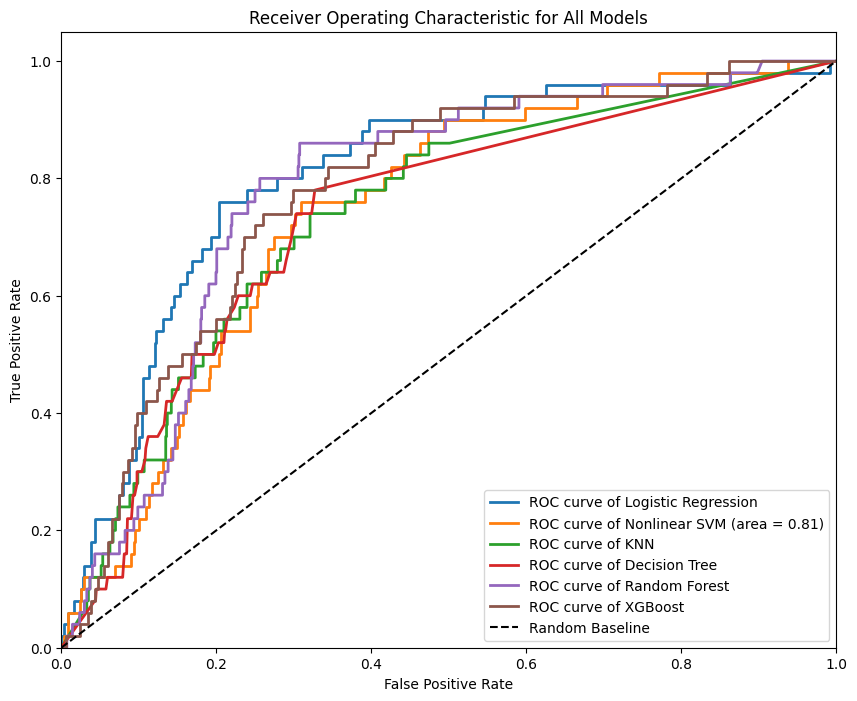

In [ ]:
plt.figure(figsize=(10, 8))
# Compute ROC curve for each class:
for name, model in best_models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_te)[:, 1]  # Probability for class 1 (stroke)
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        plt.plot(fpr, tpr, lw=2, label=f"ROC curve of {name}")
    else:
        y_score = model.decision_function(x_te)  # Use decision_function for SVM
        fpr, tpr, _ = roc_curve(y_te, y_score)
        plt.plot(fpr, tpr, lw=2, label=f"ROC curve of {name} (area = {roc_auc:.2f})")

    roc_auc = auc(fpr, tpr)
    print(f"Area under the curve of {name}:\t {roc_auc:.2f}")

# Plot the random baseline
plt.plot([0, 1], [0, 1], color="k", linestyle="--", label="Random Baseline")

# Add labels and legend
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic for All Models")
plt.legend(loc="lower right")
plt.show()

After hyperparameter optimization all the ROCs are quite good. The models who have improved the most are KNN and decision tree.

To fully evaluate the models I will also calculate accuracy, precision, recall, specificity and F1 score based on an optimized treshold.


Evalaution Metrics for Each Model:


Model: Logistic Regression
Accuracy: 0.7945
Precision: 0.1610
Recall: 0.7600
F1 Score: 0.2657
Specificity: 0.7963
Confusion Matrix:
[[774 198]
 [ 12  38]]



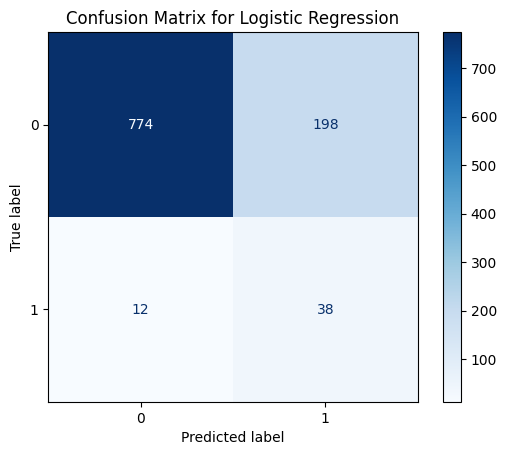



Model: Nonlinear SVM
Accuracy: 0.6937
Precision: 0.1121
Recall: 0.7600
F1 Score: 0.1954
Specificity: 0.6903
Confusion Matrix:
[[671 301]
 [ 12  38]]



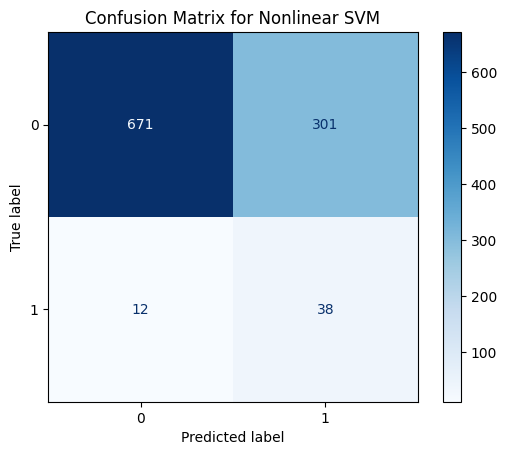



Model: KNN
Accuracy: 0.6820
Precision: 0.1060
Recall: 0.7400
F1 Score: 0.1855
Specificity: 0.6790
Confusion Matrix:
[[660 312]
 [ 13  37]]



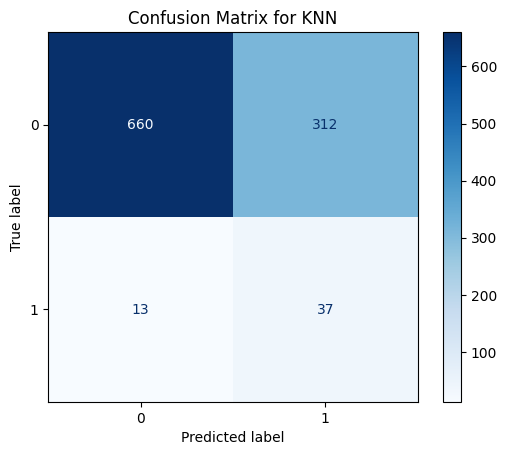



Model: Decision Tree
Accuracy: 0.6781
Precision: 0.1092
Recall: 0.7800
F1 Score: 0.1916
Specificity: 0.6728
Confusion Matrix:
[[654 318]
 [ 11  39]]



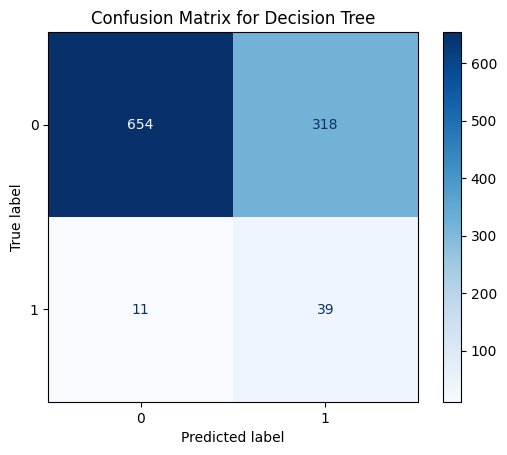



Model: Random Forest
Accuracy: 0.7006
Precision: 0.1257
Recall: 0.8600
F1 Score: 0.2194
Specificity: 0.6924
Confusion Matrix:
[[673 299]
 [  7  43]]



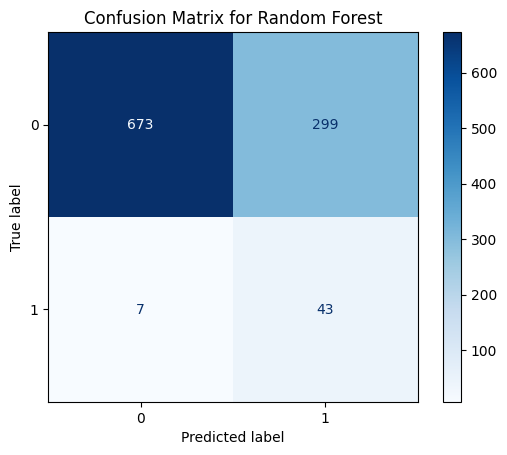



Model: XGBoost
Accuracy: 0.7045
Precision: 0.1182
Recall: 0.7800
F1 Score: 0.2053
Specificity: 0.7006
Confusion Matrix:
[[681 291]
 [ 11  39]]



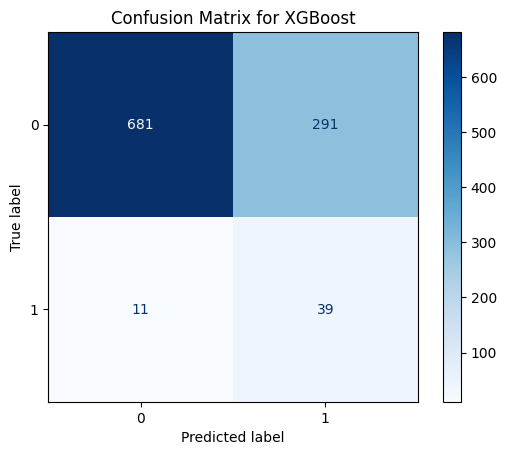

In [ ]:
 #Calculating and Printing Optimal Thresholds
print("\nEvalaution Metrics for Each Model:")
print("\n")  # Separator
for name, model in best_models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_te)[:, 1]# Store the results for each model
results = {}

# Iterate through the models and calculate metrics based on the chosen threshold
for name, model in best_models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_te)[:, 1]  # Get probabilities for class 1
    else:
        y_prob = model.decision_function(x_te)  # For models like SVM

    # Calculate the ROC curve
    fpr, tpr, thresholds = roc_curve(y_te, y_prob)

    # Determine the optimal threshold
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    # Apply the optimal threshold
    y_pred = (y_prob >= optimal_threshold).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(y_te, y_pred)
    precision = precision_score(y_te, y_pred)
    recall = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred)

    # Calculate specificity
    tn, fp, fn, tp = cm.ravel()  # Unpacking confusion matrix
    specificity = tn / (tn + fp)  # True Negatives / (True Negatives + False Positives)

    # Store results
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Specificity": specificity,
        "Confusion Matrix": cm
    }

# Print the results
for name, metrics in results.items():
    print(f"Model: {name}")
    for metric_name, metric_value in metrics.items():
        if metric_name == "Confusion Matrix":
            print(f"{metric_name}:\n{metric_value}\n")  # Print confusion matrix with newline
            # Optional: Display confusion matrix as a plot
            disp = ConfusionMatrixDisplay(confusion_matrix=metric_value, display_labels=[0, 1])
            disp.plot(cmap=plt.cm.Blues)
            plt.title(f"Confusion Matrix for {name}")
            plt.show()
        else:
            print(f"{metric_name}: {metric_value:.4f}")
    print("\n")

After considering Precision, Recall, the F1 score and the confusion matrixes I believe that logistic regression is the preferable model out of the ones I have trained.
Logistic Regression has a sensibility 0.7600 of and a specificty of 0.7963. Random Forest has a copmarable performance (with a sensibility 0.8600 of and a specificty of 0.6924) but it is way more complex.


So logistic regression is not only a good performing model but it is also the least commplex and most interpretable.

#### Intrepreting the model

Intercept: -0.85
Coefficients: ['-0.098', '2.085', '0.064', '-0.519', '0.343', '-0.010', '1.165', '0.096', '-1.146', '-0.490', '-0.998', '-4.229', '-0.548', '-1.063', '-0.560']


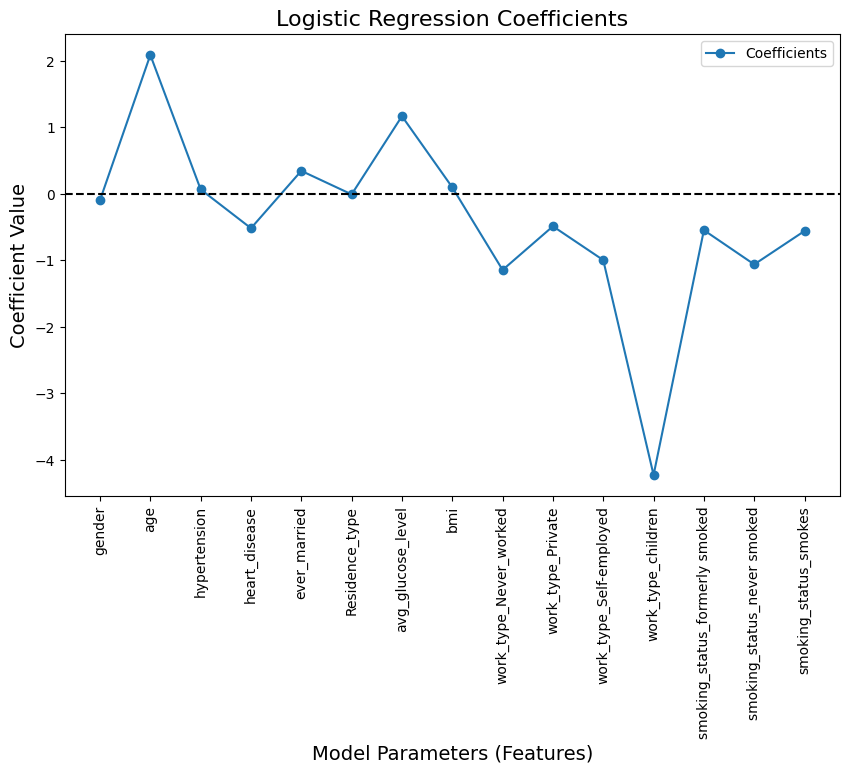

In [ ]:
# Extract the intercept and coefficients
intercept = best_models['Logistic Regression'].intercept_[0]
coefficients = best_models['Logistic Regression'].coef_[0]

# Print the intercept and coefficients
print(f"Intercept: {intercept:.2f}")
print("Coefficients:", [f"{c:.3f}" for c in coefficients])

# Plot the coefficients with reference line at y=0
plt.figure(figsize=(10, 6))
plt.plot(coefficients, marker='o', label='Coefficients')
plt.axhline(0, color='black', linestyle='--')  # Reference line at y=0
plt.xlabel("Model Parameters (Features)", size=14)
plt.ylabel("Coefficient Value", size=14)
plt.title("Logistic Regression Coefficients", size=16)

# Optional: Add feature names as x-ticks if available
# Assuming x_train.columns holds the feature names
feature_names = x_tr_res.columns
plt.xticks(ticks=range(len(coefficients)), labels=feature_names, rotation=90)

plt.legend()
plt.show()

The logistic regression model shows that age (2.085) has the strongest positive effect on the likelihood of stroke.

Hypertension (0.064) and BMI (0.096) very slightly increase the risk of stroke, but their effect is not very strong. The average glucose level (1.165), also increases stroke risk. Interestingly, heart disease appears to lower stroke risk.

Compared to people working in the private sector, other work types have different effects (the dropped category serves as a reference group):
* people whoa have never worked (-1.146) have a much lower stroke risk e^(-1.146) = 0.32
* people who are self-employed (-0.490) also have lower odds of stroke than private employees.
* children (-4.229) have an extremely negative coefficient, which is coherent with age being a very influential variable on stroke risk.

Furthermore people who formerly smoked (-0.998), never Smoked (-0.548), and surprisingly even people who currently smoke  (-1.063) have a lower stroke risk than unknown smokers.